# Project 03 · Notebook 02 — Factor Zoo: IC, Decay & Decile Spreads

Notebook 01 gave us a vetted monthly panel and a tradable universe. Now we build a small **price-only
factor zoo**, sector-neutralise it, and ask the questions a cross-sectional researcher asks *before*
running a backtest:

1. **Does each factor rank next month's returns?** → monthly rank-IC.
2. **How fast does the signal decay?** → IC vs forward horizon.
3. **Is the edge tradable in the tails?** → decile long-short spreads (gross).
4. **Do the factors diversify each other, and does a naïve composite help?**

> This notebook is *gross-of-cost and in-sample by construction* — it is signal discovery, not a
> verdict. The honest evaluation (turnover costs, purged CV, deflated Sharpe) is notebook 03. The
> survivorship caveat from notebook 01 still bounds every number here.

**Factors (all oriented so HIGH = expected outperformer):** 12-1 momentum, 1-month reversal,
low-volatility. Definitions live in `src/factors.py`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "03_equity_factor_xsection"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(PROJ / "src"))

from dataset import load_adj_close, load_universe
from factors import (build_price_factors, neutralize, rank_ic, ic_decay,
                     decile_long_short, ls_stats)

plt.rcParams["figure.figsize"] = (10, 4)
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Panel, universe and raw factors

Reuse the daily price panel and the tradable mask saved by notebook 01. The monthly grid and the three
raw factor frames come straight from `src/factors.py`.

In [2]:
px = load_adj_close()
uni = load_universe().set_index("symbol")
sector = uni["sector"].reindex(px.columns)

me   = px.resample("ME").last()
mret = me.pct_change()
fwd  = mret.shift(-1)                      # next-month return = prediction target
mask = pd.read_parquet(PROJ / "data" / "panel" / "tradable_mask.parquet")
mask.index = pd.to_datetime(mask.index)

raw = build_price_factors(px, me, mret)
print("factors:", list(raw))
print("rebalance months:", len(me), "| median tradable names:", int(mask.sum(axis=1).median()))

factors: ['mom_12_1', 'reversal_1m', 'low_vol']
rebalance months: 180 | median tradable names: 332


## 2. Sector-neutralise

Each month we cross-sectionally z-score the factor and subtract the GICS-sector mean, so the book
expresses a *within-sector* view and is not just a disguised sector bet. We confirm the residual
sector tilt is ~0 after neutralisation.

In [3]:
neutral = {name: neutralize(f, mask, sector) for name, f in raw.items()}

# sanity: mean |sector-mean| of a neutralised factor should be ~0
fz = neutral["mom_12_1"]
tilt = pd.concat({dt: fz.loc[dt].groupby(sector).mean() for dt in fz.index}, axis=1)
print(f"residual sector tilt (mom_12_1): mean |sector mean| = {tilt.abs().mean().mean():.2e}  (≈0 ✓)")
neutral["mom_12_1"].iloc[-1].dropna().describe().round(3)

residual sector tilt (mom_12_1): mean |sector mean| = 3.33e-17  (≈0 ✓)


count   349.0000
mean     -0.0000
std       0.9660
min      -1.5710
25%      -0.4440
50%      -0.1360
75%       0.2160
max      11.7420
Name: 2024-12-31 00:00:00, dtype: float64

## 3. Rank-IC — does each factor rank next month?

The **information coefficient** is the monthly Spearman correlation between the factor and the
forward return. We report its mean (edge), information ratio `mean/std` (consistency) and hit-rate.

,ic_mean,ic_ir,hit_rate,months
factor,,,,
mom_12_1,0.0041,0.0275,0.5389,167
reversal_1m,0.0092,0.0721,0.5056,178
low_vol,-0.0160,-0.0889,0.4770,174


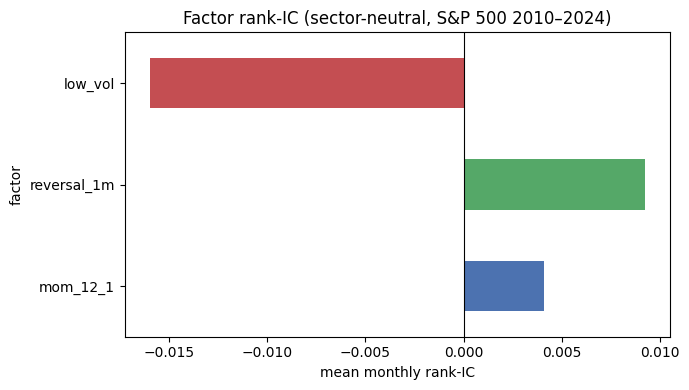

In [4]:
rows = []
ic_series = {}
for name, fz in neutral.items():
    ic = rank_ic(fz, fwd); ic_series[name] = ic
    rows.append({"factor": name, "ic_mean": ic.mean(), "ic_ir": ic.mean() / ic.std(),
                 "hit_rate": (ic > 0).mean(), "months": len(ic)})
ic_table = pd.DataFrame(rows).set_index("factor")
display(ic_table)

fig, ax = plt.subplots(figsize=(7, 4))
ic_table["ic_mean"].plot.barh(ax=ax, color=["#4c72b0", "#55a868", "#c44e52"])
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="mean monthly rank-IC", title="Factor rank-IC (sector-neutral, S&P 500 2010–2024)")
plt.tight_layout()
plt.savefig(PLOTS / "02_factor_ic.png", dpi=110, bbox_inches="tight"); plt.show()

## 4. IC decay — how long does the signal live?

Correlate each factor with the *h-month-forward* return. A factor whose IC collapses after one month
must be traded fast (and pays more cost); one with a flat decay is more forgiving.

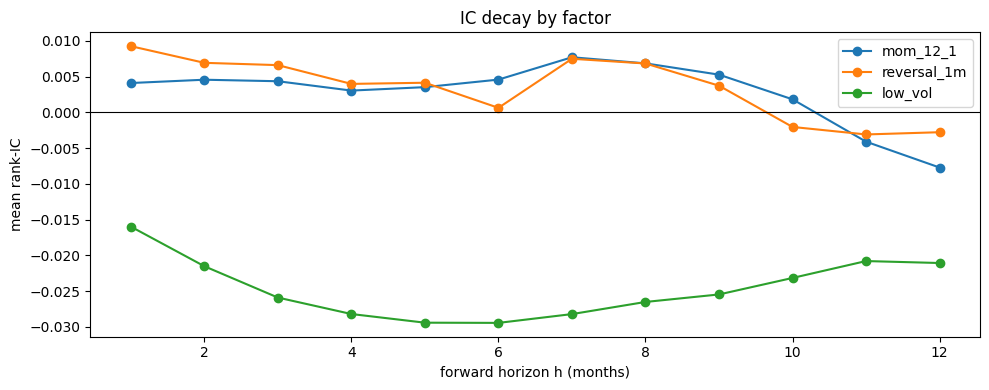

,mom_12_1,reversal_1m,low_vol
1,0.0041,0.0092,-0.0160
2,0.0046,0.0069,-0.0215
3,0.0043,0.0066,-0.0259
4,0.0030,0.0040,-0.0282
5,0.0035,0.0041,-0.0294
6,0.0046,0.0006,-0.0294
7,0.0077,0.0075,-0.0282
8,0.0068,0.0068,-0.0265
9,0.0053,0.0037,-0.0255
10,0.0018,-0.0020,-0.0231


In [5]:
decay = pd.DataFrame({name: ic_decay(fz, me, hmax=12) for name, fz in neutral.items()})
fig, ax = plt.subplots()
decay.plot(ax=ax, marker="o")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="forward horizon h (months)", ylabel="mean rank-IC",
       title="IC decay by factor")
plt.tight_layout()
plt.savefig(PLOTS / "02_ic_decay.png", dpi=110, bbox_inches="tight"); plt.show()
decay.round(4)

## 5. Decile long-short spreads (gross)

The IC measures the *whole-ranking* relationship; a tradable book lives in the **tails**. We sort each
month into deciles and hold a top-minus-bottom, equal-weight book. Reported gross (no costs) — a
sobering number once notebook 03 adds turnover costs.

,ann_return,sharpe,t_stat
mom_12_1,2.5000,0.1700,0.6400
reversal_1m,0.2000,0.0100,0.0500
low_vol,-13.5000,-0.6800,-2.5800


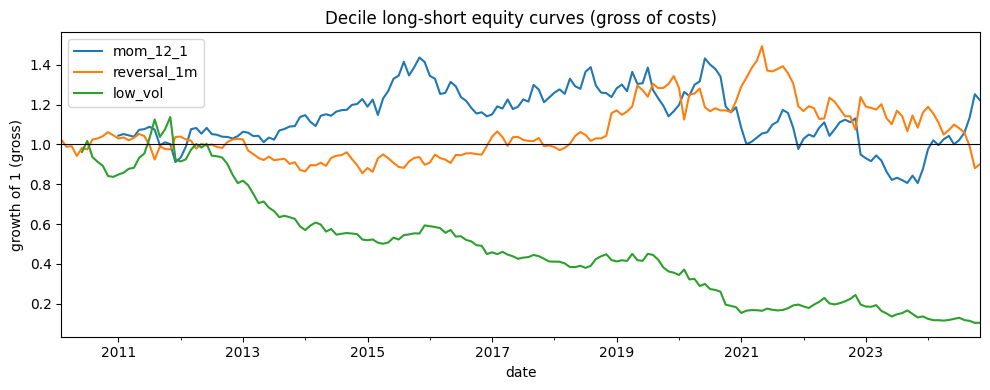

In [6]:
ls = {name: decile_long_short(fz, fwd) for name, fz in neutral.items()}
stats = pd.DataFrame({name: ls_stats(s) for name, s in ls.items()}).T
stats["ann_return"] = (stats["ann_return"] * 100).round(1)
display(stats.round(2))

fig, ax = plt.subplots()
for name, s in ls.items():
    (1 + s).cumprod().plot(ax=ax, label=name)
ax.axhline(1, color="k", lw=0.8); ax.legend()
ax.set(ylabel="growth of 1 (gross)", xlabel="date",
       title="Decile long-short equity curves (gross of costs)")
plt.tight_layout()
plt.savefig(PLOTS / "02_decile_ls.png", dpi=110, bbox_inches="tight"); plt.show()

## 6. Diversification & a naïve composite

Low pairwise correlation is what makes combining factors attractive *in theory*. But a naïve
equal-weight composite blindly averages signals — including any with the **wrong sign in this sample**.
We test whether that mechanical stacking helps or hurts.

In [7]:
corr = pd.DataFrame(
    {a: {b: np.nanmean([neutral[a].loc[dt].corr(neutral[b].loc[dt])
                        for dt in neutral[a].index if dt in neutral[b].index])
         for b in neutral} for a in neutral}
)
print("avg cross-sectional factor correlation:")
display(corr.round(2))

composite = sum(neutral.values()) / len(neutral)
ic_c = rank_ic(composite, fwd); ls_c = decile_long_short(composite, fwd)
print(f"naïve equal-weight composite:  IC {ic_c.mean():+.4f} (IR {ic_c.mean()/ic_c.std():+.3f})   "
      f"decile L/S ann {ls_stats(ls_c)['ann_return']*100:+.1f}%  Sharpe {ls_stats(ls_c)['sharpe']:+.2f}")

avg cross-sectional factor correlation:


,mom_12_1,reversal_1m,low_vol
mom_12_1,1.0000,-0.0300,-0.1100
reversal_1m,-0.0300,1.0000,0.0500
low_vol,-0.1100,0.0500,1.0000


naïve equal-weight composite:  IC +0.0033 (IR +0.024)   decile L/S ann -5.5%  Sharpe -0.41


## 7. Findings (S&P 500, 2010–2024, sector-neutral, gross)

- **All three signals are weak** on this survivorship-tinted mega-cap universe — rank-ICs are single
  basis points, well below the ~0.03+ you would want from a standalone factor.
- **Reversal has the best IC (~+0.009) but no tail edge:** its decile L/S is ~0% — the relationship is
  in the broad ranking, not the extremes, and it **decays to zero within ~5 months**. A fast-turnover,
  cost-hungry signal with little to monetise.
- **Momentum is the only positive decile book (~+2.5%/yr) but statistically insignificant** (t≈0.6)
  and its IC, though tiny, is the most *persistent* across horizons.
- **Low-volatility has the WRONG sign here** — sector-neutral low-vol *underperforms* by ~13%/yr
  (t≈−2.6). The classic low-vol anomaly does **not** hold inside the S&P 500 over a tech-led bull
  market; high-beta names won. This is a regime/universe finding, not a bug.
- **The naïve equal-weight composite loses** (negative decile spread) precisely because it averages in
  the wrong-sign low-vol factor. Mechanically stacking factors without regard to sign/quality destroys
  value — the central lesson of this notebook.
- Factors are nearly uncorrelated (|ρ|≤0.11), so a *sign-aware, validated* combination is still worth
  testing — but only out-of-sample.

**Next — notebook 03:** build the long-short book properly — orient/weight factors **without
look-ahead** (rolling IC weights), charge realistic **turnover costs** (~10 bps/side), evaluate under
**purged K-fold CV**, and judge the result with a **deflated Sharpe** (`lib/backtest.py`). The honest
prior after this notebook: the gross edge is too thin to expect it to survive costs — and proving that
rigorously is the deliverable.